# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [96]:
# Import the four packages here.
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path
import pandas as pd

## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [97]:
boundary_path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"
# Read the boundary.

maine_boundary = gpd.read_file(boundary_path)
# Print its CRS and shape.
print(maine_boundary.shape)
print(maine_boundary.crs)
# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()

#maine_boundary.explore()

(6204, 10)
EPSG:4326


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [98]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [99]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims) #what is in the raster
print("Shape:", bio1.shape) #how many rows and columns in the data
print("Data type:", bio1.dtype) #the type of data which tells python how to handle it
print("CRS:", bio1.rio.crs) #the cordinate refrence system
print("Resolution:", bio1.rio.resolution()) #how much each pixal covers
print("Bounds:", bio1.rio.bounds()) #the bounds of the raster with cordinates
print("NoData:", bio1.rio.nodata) #how no data is labled



Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [100]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [101]:
# Compare global and clipped metadata here.

print("Shape:", bio1.shape)
print("CRS:", bio1.rio.crs)
print("Resolution:", bio1.rio.resolution())
print("Bounds:", bio1.rio.bounds())


print("Shape:", bio1_maine.shape)
print("CRS:", bio1_maine.rio.crs)
print("Resolution:", bio1_maine.rio.resolution())
print("Bounds:", bio1_maine.rio.bounds())




Shape: (1, 4320, 8640)
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
Shape: (109, 101)
CRS: EPSG:4326
Resolution: (0.04166666666666671, -0.041666666666666664)
Bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)


**Your comparison: The CRS and resolution stayed the same while the shape and bounds changed. **

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

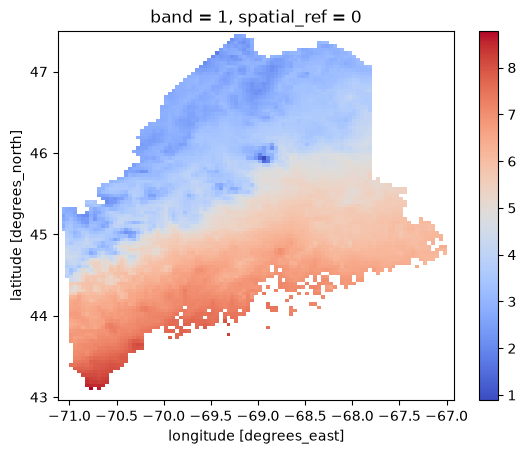

In [102]:
# Plot bio1_maine here.

bio1_maine.plot(cmap = "coolwarm")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:**
Min temperature of coldest month because this gives us our low thermal threshold for species that are not cold tolerant
**Variable 2 and justification:**
max temperature of the warmest month because this gives us our high thermal threshold for species that are not heat tolerant
**Variable 3 and justification:**
annual percipitation because amphibians need water to stay hydrated

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [103]:
# Open your first additional raster.
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio6_path = bioclim_path / "wc2.1_2.5m_bio_6.tif"

bio6 = rxr.open_rasterio(
    bio6_path,
    masked=True,
)



# Inspect its metadata.

print("Shape:", bio6.shape)
print("CRS:", bio6.rio.crs)
print("Resolution:", bio6.rio.resolution())
print("Bounds:", bio6.rio.bounds())




Shape: (1, 4320, 8640)
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [104]:
# Compare the first additional raster with bio1.

print("Same CRS:", bio1.rio.crs == bio6.rio.crs)
print("Same shape:", bio1.shape == bio6.shape)
print("Same resolution:", bio1.rio.resolution() == bio6.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio6.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

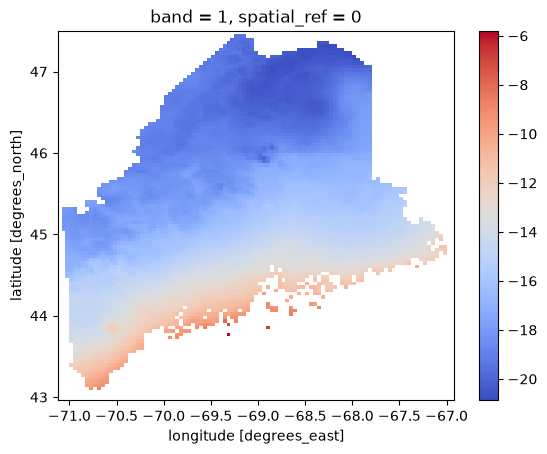

In [105]:
# Clip, squeeze, and plot the first additional raster.
bio6_maine = bio6.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio6_maine = bio6_maine.squeeze()

bio6_maine.plot(cmap = "coolwarm")

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

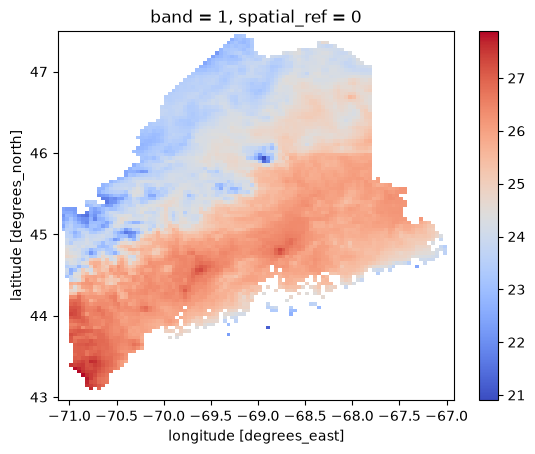

In [106]:
# Complete the workflow for the second additional raster.


bioclim_path = Path("/home/jovyan/shared/bioclim")
bio5_path = bioclim_path / "wc2.1_2.5m_bio_5.tif"

bio5 = rxr.open_rasterio(
    bio5_path,
    masked=True,
)




bio5_maine = bio5.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio5_maine = bio5_maine.squeeze()

bio5_maine.plot(cmap = "coolwarm")

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  11246
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

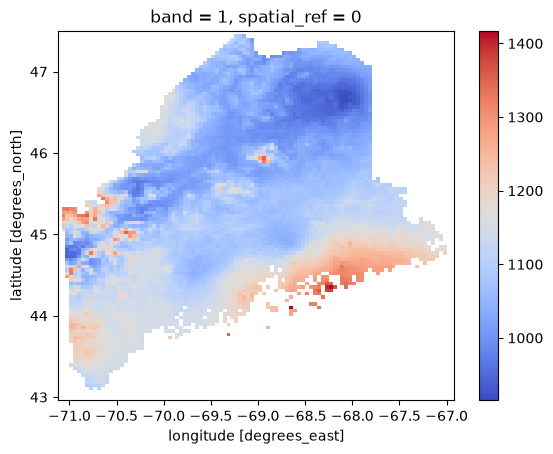

In [107]:
# Complete the workflow for the third additional raster.
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio12_path = bioclim_path / "wc2.1_2.5m_bio_12.tif"

bio12 = rxr.open_rasterio(
    bio12_path,
    masked=True,
)


bio12_maine = bio12.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio12_maine = bio12_maine.squeeze()

bio12_maine.plot(cmap = "coolwarm")
bio12

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [108]:
amphibians = pd.read_csv(
    "Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

# Keep the five requested columns.

columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "year",
]


## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [109]:
# Convert both coordinate columns with pd.to_numeric().
# Convert decimalLongitude to numeric.

amphibians["decimalLongitude"] = pd.to_numeric(
    amphibians["decimalLongitude"], errors="coerce"
)

# Convert decimalLatitude to numeric.

amphibians["decimalLatitude"] = pd.to_numeric(
    amphibians["decimalLatitude"], errors="coerce"
)
# Drop rows missing species, longitude, or latitude.
amphibians = amphibians.dropna(
    subset=["species", "decimalLongitude", "decimalLatitude"]
).copy()





## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [110]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1: Ambystoma maculatum*

**Species 2: Plethodon cinereus**

**Species 3: Lithobates palustris**

In [111]:
selected_species = [
    "Ambystoma maculatum",
    "Plethodon cinereus",
    "Lithobates palustris",
]

# Filter the occurrence table with .isin(selected_species).

filtered_amphibians = amphibians[amphibians["species"].isin(selected_species)]


## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [112]:
# Create selected_amphibians_gdf here.
selected_amphibians = gpd.GeoDataFrame(
    filtered_amphibians,
    geometry=gpd.points_from_xy(
        filtered_amphibians["decimalLongitude"],
        filtered_amphibians["decimalLatitude"],
    ),
    crs="EPSG:4326",
)

selected_amphibians.head()


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue,geometry
3,6520721493,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39528...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,2026-08-28T19:26:37,CC_BY_NC_4_0,birdie111,birdie111,NaN,NaN,2026-09-11T05:24:26.003Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-68.63679 44.86047)
7,6520700408,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39597...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,2026-08-30T23:30:18,CC_BY_NC_4_0,kmaybay,kmaybay,NaN,NaN,2026-09-11T05:25:22.790Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-69.86566 44.36192)
11,6520663387,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39191...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,2026-08-23T05:04:34,CC_BY_NC_4_0,craigjb,craigjb,NaN,NaN,2026-09-11T05:25:19.544Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-69.81189 43.81535)
16,6520617346,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39672...,Animalia,Chordata,Amphibia,Caudata,Plethodontidae,Plethodon,Plethodon cinereus,...,2026-09-02T18:30:52,CC_BY_NC_4_0,Emily,Emily,NaN,NaN,2026-09-11T06:05:45.508Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-70.45687 43.99431)
21,6520600766,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39672...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,2026-09-02T18:36:26,CC_BY_NC_4_0,Noah Nadeau,Noah Nadeau,NaN,NaN,2026-09-11T05:59:41.606Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-69.64615 44.73535)


## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [113]:
# Print both coordinate systems.

print(selected_amphibians.crs)

print("CRS:", bio6.rio.crs)
print("CRS:", bio5.rio.crs)
print("CRS:", bio12.rio.crs)
print("CRS:", bio1.rio.crs)

EPSG:4326
CRS: EPSG:4326
CRS: EPSG:4326
CRS: EPSG:4326
CRS: EPSG:4326


**Your explanation: The cordinate refrence system for all the rasters and occurences must be alligned**

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [114]:
# Create point_x from point longitude.

point_x = xr.DataArray(
    selected_amphibians.geometry.x.to_numpy(),
    dims="record",
)



# Create point_y from point latitude.


point_y = xr.DataArray(
    selected_amphibians.geometry.y.to_numpy(),
    dims="record",
)


## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [115]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)


# Add the values to selected_amphibians_gdf.

selected_amphibians["bio1_mean_temp_c"] = bio1_values
selected_amphibians.head()

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue,geometry,bio1_mean_temp_c
3,6520721493,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39528...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,CC_BY_NC_4_0,birdie111,birdie111,NaN,NaN,2026-09-11T05:24:26.003Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-68.63679 44.86047),6.544000
7,6520700408,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39597...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,CC_BY_NC_4_0,kmaybay,kmaybay,NaN,NaN,2026-09-11T05:25:22.790Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-69.86566 44.36192),6.777333
11,6520663387,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39191...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,CC_BY_NC_4_0,craigjb,craigjb,NaN,NaN,2026-09-11T05:25:19.544Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-69.81189 43.81535),7.709868
16,6520617346,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39672...,Animalia,Chordata,Amphibia,Caudata,Plethodontidae,Plethodon,Plethodon cinereus,...,CC_BY_NC_4_0,Emily,Emily,NaN,NaN,2026-09-11T06:05:45.508Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-70.45687 43.99431),6.875500
21,6520600766,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39672...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,CC_BY_NC_4_0,Noah Nadeau,Noah Nadeau,NaN,NaN,2026-09-11T05:59:41.606Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-69.64615 44.73535),6.332833


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [117]:
# Count missing extracted BIO1 values.


selected_amphibians["bio1_mean_temp_c"].isna().value_counts()



bio1_mean_temp_c
False    6128
True      873
Name: count, dtype: int64

**Your explanation: The cordinates might be valid but they might be on the ocean in a coastel envrionment so then they would be na for amphibians because they do not live in the ocean**

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [118]:
# Extract values from the first additional clipped raster.
bio5_values = bio5_maine.sel(x=point_x, y=point_y, method="nearest")

# Add the values to selected_amphibians_gdf.

selected_amphibians["bio5_warmest_max_c"] = bio5_values

In [119]:
# Extract values from the second additional clipped raster.
bio6_values = bio6_maine.sel(x=point_x, y=point_y, method="nearest")

# Add the values to selected_amphibians_gdf.
selected_amphibians["bio6_coldest_min_c"] = bio6_values


In [120]:
# Extract values from the third additional clipped raster.
bio12_values = bio12_maine.sel(x=point_x, y=point_y, method="nearest")
# Add the values to selected_amphibians_gdf.
selected_amphibians["bio12_annual_precip_mm"] = bio12_values

## 23. Create the occurrence-environment table
Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.




In [121]:
# Create and display occurrence_environment.


occurrence_environment = selected_amphibians.drop(columns="geometry")

occurrence_environment.head()


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue,bio1_mean_temp_c,bio5_warmest_max_c,bio6_coldest_min_c,bio12_annual_precip_mm
3,6520721493,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39528...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,birdie111,NaN,NaN,2026-09-11T05:24:26.003Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,6.544000,26.608000,-13.752000,1057.0
7,6520700408,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39597...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,kmaybay,NaN,NaN,2026-09-11T05:25:22.790Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,6.777333,26.364000,-13.428000,1104.0
11,6520663387,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39191...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,craigjb,NaN,NaN,2026-09-11T05:25:19.544Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,7.709868,24.947369,-9.773685,1156.0
16,6520617346,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39672...,Animalia,Chordata,Amphibia,Caudata,Plethodontidae,Plethodon,Plethodon cinereus,...,Emily,NaN,NaN,2026-09-11T06:05:45.508Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,6.875500,26.136000,-13.396000,1162.0
21,6520600766,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/39672...,Animalia,Chordata,Amphibia,Anura,Ranidae,Lithobates,Lithobates palustris,...,Noah Nadeau,NaN,NaN,2026-09-11T05:59:41.606Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,6.332833,26.612000,-14.944000,1051.0


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [122]:
# Calculate species-level summaries here.
predictor_columns = [
    "bio1_mean_temp_c",
    "bio5_warmest_max_c",
    "bio6_coldest_min_c",
    "bio12_annual_precip_mm",
]
for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].mean())



Ambystoma maculatum 2511 
 bio1_mean_temp_c             6.158210
bio5_warmest_max_c          25.551662
bio6_coldest_min_c         -13.933883
bio12_annual_precip_mm    1144.519107
dtype: float64
Lithobates palustris 1626 
 bio1_mean_temp_c             6.591896
bio5_warmest_max_c          25.806078
bio6_coldest_min_c         -13.189041
bio12_annual_precip_mm    1177.958603
dtype: float64
Plethodon cinereus 2864 
 bio1_mean_temp_c             6.868341
bio5_warmest_max_c          25.553639
bio6_coldest_min_c         -12.233288
bio12_annual_precip_mm    1178.368842
dtype: float64


## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [123]:
# Select the four predictor columns and calculate .corr().


occurrence_environment[predictor_columns].corr().round(2)

,bio1_mean_temp_c,bio5_warmest_max_c,bio6_coldest_min_c,bio12_annual_precip_mm
bio1_mean_temp_c,1.00,0.37,0.95,0.45
bio5_warmest_max_c,0.37,1.00,0.06,-0.28
bio6_coldest_min_c,0.95,0.06,1.00,0.58
bio12_annual_precip_mm,0.45,-0.28,0.58,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning. mean temperature and coldest temperature are closely corelated. Annual percipitation and coldest min temp are are corellated although not as strongly. I think I would maybe remove mean temp due to its strong correlation and lack of strong biological importance. 

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [124]:
# Save occurrence_environment with .to_csv().
occurrence_environment.to_csv(
    "Lab05_environmental_values.csv",
    index=False,
)



## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact?
both of these variables give the miniumum area of cover for its assoicated data. So if they overlap you may have error because you are adding the uncertinity along with with resulution as possible areas which you are refrencing. 

2. What environmental variation is lost when all occurrences in one raster cell receive the same value?
You lose microclimate variations. For example the difference in environmnet an organisms experinces when its under a tree compared to in a field in the same pixal.
3. Which predictor has the strongest biological justification for your selected species?
Coldest min temperature has the strongest justification. Amphibians tend to be cold limited so this is likely a very important predictor for range.
4. Which preprocessing choice is most important to document for reproducibility?
you must document the crs you used in order to reproduce these findings. Also it should be documented that you removed observations with no species or cordinates is. 
5. Name one additional environmental predictor you would seek for an amphibian study and explain why.
I would maybe think about distance from ponds/lakes/freshwater sources. I do not know a ton about amphibians but I do know that freshwater is very important for their survival.

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```